In [2]:
import numpy as np
import pandas as pd
import yaml
import os

"""
Loading data for processing.
8 experiment conditions with (potentially) multiple trials per condition,
each trial is in it's own subdirectory
each trial has data split into multiple files
    - experiment_config.yaml
    - hardware_config.yaml
    - energy.csv
    - hop_{i}.csv

Placing trials of each condition into a dictionary as:
conditions = {
    condition_string : [
        {
            'experiment_config': experiment config dictionary from yaml,
            'hardware_config': hardware config dictionary from yaml,
            'energy': energy data in Pandas Dataframe from csv,
            'hops' : [Pandas Dataframe per hop csv file]
        }, ... , repeat for each trial
    ]
}
"""


directory = r'C:\Users\Joseph Sullivan\Documents\hsa_hopper_control\data\2_29_25\use'
# directory = r'C:\Users\Joseph Sullivan\Documents\hsa_hopper_control\data\hop_experiments\design_paper'
condition_strings = os.listdir(directory)
conditions = {}
for cond in condition_strings:
    cond_path = os.path.join(directory, cond)
    trial_folders = os.listdir(cond_path)
    trials = []
    for tf in trial_folders:
        trial_path = os.path.join(cond_path, tf)
        with open(os.path.join(trial_path, 'experiment_config.yaml')) as f: 
            exp_config = yaml.load(f, yaml.Loader)
        with open(os.path.join(trial_path, 'hardware_config.yaml')) as f: 
            hard_config = yaml.load(f, yaml.Loader)
        # energy = pd.read_csv(os.path.join(trial_path, 'energy.csv'))
        hop_files = [hf for hf in os.listdir(trial_path) if 'hop' in hf]
        hops = [None]*len(hop_files)
        for hf in hop_files:
            parts = os.path.splitext(hf)
            file_idx = int((parts[0].split('_'))[-1])
            hop_path = os.path.join(trial_path, hf)
            df = pd.read_csv(os.path.join(trial_path, hf))
            df['file_idx'] = len(df)*file_idx
            hops[file_idx] = df

        data = pd.concat(hops, ignore_index=True)
        trials.append({
            'experiment_config' : exp_config,
            'hardware_config' : hard_config,
            'data' : data
        })
        conditions[cond] = trials

In [5]:
""" How to fucking do data segmentation ?"""

from hsa_hopper.kinematics import KinematicParameters, forward_kinematics
from hsa_hopper.collocation import interp_covector, diff_tensor, interp_tensor
from hsa_hopper.controller import HopController

""" We need to, as accurately as possible, isolate the touch-down time.
    This occurs shortly before the controller mode switches from flight to stance0.

    Probably best to do the data filtering now, rather than after segmentation.
    Then I can add a "hop index" column to the data frames once segmentation is figured out.
"""

""" So we are filtering then. """

# trials = conditions['hsa_1900g']
for condition, trials in conditions.items():
    for trial in trials:
        # model parameters
        kin_params = trial['hardware_config']['kinematics']
        params = KinematicParameters(kin_params['a'],kin_params['b'],kin_params['c'],kin_params['d'])
        total_mass = float(trial['experiment_config']['mass'])/1e3

        # raw data
        df = trial['data']
        x_raw = df['x_rad'].to_numpy()
        # y_raw = forward_kinematics(params, x_raw)[0]
        t_s = df['t_s'].to_numpy()
        tau_raw = df['torque'].to_numpy()

        # output arrays
        x = np.zeros_like(x_raw)
        xdot = np.zeros_like(x)
        xddot = np.zeros_like(x)

        # y = np.zeros_like(y_raw)
        # ydot = np.zeros_like(y)
        # yddot = np.zeros_like(y)

        tau = np.zeros_like(tau_raw)
        
        # savgol filtering params
        degree = 2
        window = 7

        # savgol filtering loop
        N_timestamps = t_s.size
        for i in range(N_timestamps):
            start_idx = max(0,i-window//2)
            stop_idx = min(N_timestamps,start_idx+window)
            A = np.vstack(
                [interp_covector(t_s[j],t_s[start_idx],t_s[stop_idx-1],degree+1)
                    for j in range(start_idx,stop_idx)]
            )
            t_eval = interp_covector(t_s[i],t_s[start_idx],t_s[stop_idx-1],degree+1)
            dt = diff_tensor(t_s[start_idx], t_s[stop_idx-1], degree+1)

            x_coeffs, res, rank, s = np.linalg.lstsq(A,x_raw[start_idx:stop_idx],rcond=None)
            x[i] = np.dot(t_eval, x_coeffs)[0]
            xdot[i] = np.dot(t_eval, dt@x_coeffs)[0]
            xddot[i] = np.dot(t_eval, dt@(dt@x_coeffs))[0]

            A = np.vstack(
                [interp_covector(t_s[j],t_s[start_idx],t_s[stop_idx-1],degree-1)
                    for j in range(start_idx, stop_idx)]
            )
            t_eval = interp_covector(t_s[i],t_s[start_idx],t_s[stop_idx-1],degree-1)
            tau_coeffs, res, rank, s = np.linalg.lstsq(A,tau_raw[start_idx:stop_idx],rcond=None)
            tau[i] = np.dot(t_eval, tau_coeffs)[0]

        fk,jac,hess = forward_kinematics(params, x, jacobian=True, hessian=True)
        df['x_rad'] = x
        df['xdot'] = xdot
        df['xddot'] = xddot
        df['y_m'] = fk[0]
        df['ydot'] = jac[0]*xdot
        df['yddot'] = jac[0]*xddot + hess[0]*xdot**2
        df['torque'] = tau
        df['dydx'] = jac[0]
        df['d2yd2x'] = hess[0]
        trial['data'] = df

In [6]:
"""
Looks like I can use the yddot estimates to determine the stance time, by taking slices based on the file index,
and then finding the timestamp where yddot is minimal.
"""

for cond, trials in conditions.items():
    for trial in trials:
        df = trial['data']
        file_indices = df['file_idx'].unique()

        # add a new column for the hop index
        df['hop_idx'] = len(df)*[-1]

        last_frame = df['file_idx'] == file_indices[0]

        last_td_idx = df.loc[last_frame,'yddot'].idxmin()-2
        ALL_STANCE0 = df['mode'] == HopController._STANCE0
        for i in range(1,len(file_indices)-1):

            # get frame index of min yddot in this dataframe
            this_frame = df['file_idx'] == file_indices[i]
            next_td_idx = df.loc[this_frame,'yddot'].idxmin()-2

            # change mode to reflect correction
            stance_frame = this_frame & ALL_STANCE0
            stance0_idx = df.loc[stance_frame, 'mode'].idxmin()
            df.loc[last_td_idx:stance0_idx, 'mode'] = HopController._STANCE0

            # set hop_idx at last_td_idx:next_td_idx to i-1
            df.loc[last_td_idx:next_td_idx, 'hop_idx'] = i-1


            # update last_frame and last_td_idx
            last_frame = this_frame
            last_td_idx = next_td_idx 

        # drop rows with hop_idx = -1
        trial['data'] = df[df['hop_idx'] != -1]

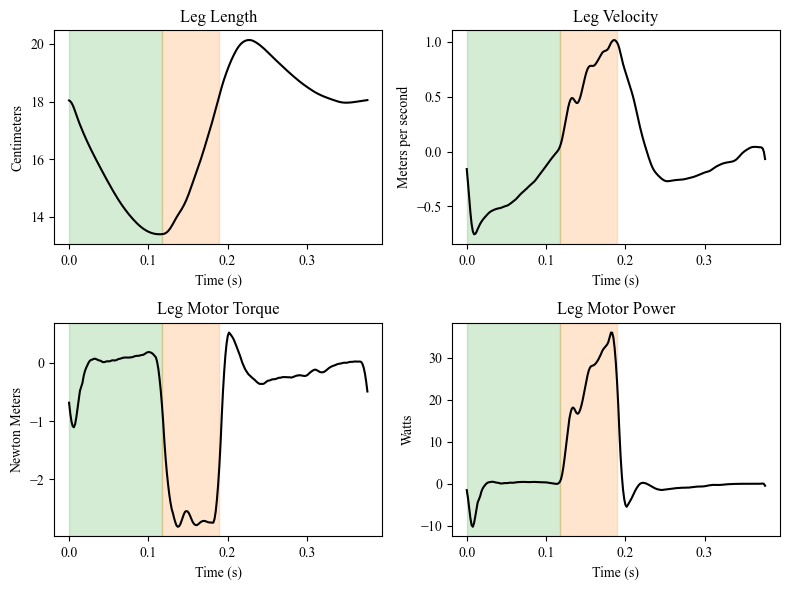

In [82]:
from matplotlib import pyplot as plt
cond = 'hsa_1500g'
trials = conditions[cond]
df = trials[0]['data']
for hop in df['hop_idx'].unique():
    frame = df['hop_idx'] == hop
    t = df.loc[frame, 't_s'].to_numpy()
    tau = df.loc[frame, 'torque'].to_numpy()
    x = df.loc[frame, 'x_rad'].to_numpy()
    y = df.loc[frame, 'y_m'].to_numpy()
    ydot = df.loc[frame, 'ydot'].to_numpy()
    xdot = df.loc[frame, 'xdot'].to_numpy()
    xddot = df.loc[frame, 'xddot'].to_numpy()
    mode = df.loc[frame, 'mode'].to_numpy()
fig, axs = plt.subplots(nrows=2,ncols=2, figsize=(8,6))

i_stance1 = next(i for i in range(len(mode)) if mode[i] == HopController._STANCE1)
i_flight = next(i for i in range(len(mode)) if mode[i] == HopController._FLIGHT)
t = t-t[0]
axs[0,0].set_title('Leg Length')
axs[0,0].plot(t, 100*y, color='black')
axs[0,0].axvspan(t[0], t[i_stance1], alpha=.2, color='C3')
axs[0,0].axvspan(t[i_stance1], t[i_flight], alpha=.2, color='C4')
axs[0,0].set_xlabel('Time (s)')
axs[0,0].set_ylabel('Centimeters')

axs[0,1].set_title('Leg Velocity')
axs[0,1].plot(t, ydot, color='black')
axs[0,1].axvspan(t[0], t[i_stance1], alpha=.2, color='C3')
axs[0,1].axvspan(t[i_stance1], t[i_flight], alpha=.2, color='C4')
axs[0,1].set_xlabel('Time (s)')
axs[0,1].set_ylabel('Meters per second')

axs[1,0].set_title('Leg Motor Torque')
axs[1,0].plot(t, tau, color='black')
axs[1,0].axvspan(t[0], t[i_stance1], alpha=.2, color='C3')
axs[1,0].axvspan(t[i_stance1], t[i_flight], alpha=.2, color='C4')
axs[1,0].set_xlabel('Time (s)')
axs[1,0].set_ylabel('Newton Meters')

axs[1,1].set_title('Leg Motor Power')
axs[1,1].plot(t, tau*xdot, color='black')
axs[1,1].axvspan(t[0], t[i_stance1], alpha=.2, color='C3')
axs[1,1].axvspan(t[i_stance1], t[i_flight], alpha=.2, color='C4')
axs[1,1].set_xlabel('Time (s)')
axs[1,1].set_ylabel('Watts')
fig.tight_layout()
fig.savefig('exmaple_trajectory.png', dpi=900)
# plt.plot(t-t[0],100*y)
# plt.plot(t-t[0],tau)

In [8]:
"""
drop any incomplete hops from data frames
"""
for cond, trials in conditions.items():
    for trial in trials:
        df = trial['data']
        hop_indices = df['hop_idx'].unique()
        for idx in hop_indices:
            hop_frame = df['hop_idx'] == idx
            modes = df.loc[hop_frame, 'mode'].unique()
            if HopController._STANCE0 not in modes:
                df.loc[hop_frame, 'hop_idx'] = -1
            if HopController._STANCE1 not in modes:
                df.loc[hop_frame, 'hop_idx'] = -1
            if HopController._FLIGHT not in modes:
                df.loc[hop_frame, 'hop_idx'] = -1
            t = df.loc[hop_frame, 't_s']
        trial['data'] = df[df['hop_idx'] != -1]


In [9]:
# Now that we have that segmented the data better, we can do work calculations with a more detailed inertial model
J = 3.5e-3                # motor inertia (approx)
m_foot = 0.
m_cart = 1.3-m_foot
R = 3*.095              # motor effective resistance
Kv = 105*(2*np.pi/60)/6 # motor constant from datasheet (Volts*s/rad)
Kt = 1/Kv               # motor constant in Nm/A
Kfudge = .78            # QDD torque model factor

for cond, trials in conditions.items():
    for trial_idx, trial in enumerate(trials):
        summary = {
            'HSA' : [],
            'Mass': [],
            'Hop Height' : [],
            'Max Leg Length': [],
            'Min Leg Length': [],
            'Period' : [],
            'Electrical Loss': [],
            'Thermal Loss': [],
            'Stance Positive Motor Work': [],
            'Stance Negative Motor Work': [],
            'Positive Motor Work': [],
            'Negative Motor Work': [],
            'Stance Positive Joint Work': [],
            'Stance Negative Joint Work': [],
            'Positive Joint Work': [],
            'Negative Joint Work': [],
            'Trial Index' : trial_idx,
        }
        df = trial['data']
        m_weight = trial['experiment_config']['mass']/1000-1.3
        ALL_STANCE0 = df['mode'] == HopController._STANCE0
        ALL_STANCE1 = df['mode'] == HopController._STANCE1
        ALL_STANCE = ALL_STANCE0 | ALL_STANCE1
        ALL_FLIGHT = df['mode'] == HopController._FLIGHT
        hop_indices = df['hop_idx'].unique()
        for hop_idx in hop_indices:
            hop_frame = df['hop_idx'] == hop_idx
            stance_frame = hop_frame & ALL_STANCE
            flight_frame = hop_frame & ALL_FLIGHT

            # get relevant data
            t = df.loc[hop_frame, 't_s'].to_numpy()
            x = df.loc[hop_frame,'x_rad'].to_numpy()
            xdot = df.loc[hop_frame,'xdot'].to_numpy()
            xddot = df.loc[hop_frame,'xddot'].to_numpy()
            y = df.loc[hop_frame,'y_m'].to_numpy()
            ydot = df.loc[hop_frame,'ydot'].to_numpy()
            yddot = df.loc[hop_frame,'yddot'].to_numpy()
            tau = df.loc[hop_frame, 'torque'].to_numpy()
            mode = df.loc[hop_frame, 'mode'].to_numpy()

            flight_start = next(i for i in range(x.size) if mode[i] == HopController._FLIGHT)

            # pull back a couple flight indices into the stance index
            therm_power = R*(tau[:flight_start]/(Kt*Kfudge))**2
            motor_power = tau[:flight_start] * xdot[:flight_start]
            joint_power = (J*xddot[:flight_start])*xdot[:flight_start] + ((m_cart+m_weight)*(yddot+9.81)[:flight_start])*ydot[:flight_start]

            stance_therm_loss= np.trapz(therm_power, x=t[:flight_start])
            stance_pos_motor_work = np.trapz(np.clip(motor_power, 0, np.inf), x=t[:flight_start])
            stance_neg_motor_work = np.trapz(np.clip(motor_power, -np.inf, 0), x=t[:flight_start])
            stance_pos_joint_work = np.trapz(np.clip(joint_power, 0, np.inf), x=t[:flight_start])
            stance_neg_joint_work = np.trapz(np.clip(joint_power, -np.inf, 0), x=t[:flight_start])

            print(f'{cond}, hop_idx={hop_idx}')
            print('Stance work:')
            print(f'Thermal loss: {stance_therm_loss}')
            print(f'Motor work: {(stance_pos_motor_work, stance_neg_motor_work)}')
            print(f'Joint work: {(stance_pos_joint_work, stance_neg_joint_work)}')

            # print(stance_pos_motor_work + stance_neg_motor_work)
            # print(stance_pos_joint_work + stance_neg_joint_work)
            xdot_initial = xdot[0]
            xdot_final = xdot[flight_start]
            y_initial = y[0]
            y_final = y[flight_start]
            ydot_initial = ydot[0]
            ydot_final = ydot[flight_start]
            y_min = np.min(y[:flight_start])
            h = (ydot_final**2)/(2*9.81)

            therm_power = R*(tau[flight_start:]/(Kt*Kfudge))**2
            motor_power = tau[flight_start:] * xdot[flight_start:]
            joint_power = (J*xddot[flight_start:])*xdot[flight_start:] + (m_foot*yddot[flight_start:])*ydot[flight_start:]

            flight_therm_loss= np.trapz(therm_power, x=t[flight_start:])
            flight_pos_motor_work = np.trapz(np.clip(motor_power, 0, np.inf), x=t[flight_start:])
            flight_neg_motor_work = np.trapz(np.clip(motor_power, -np.inf, 0), x=t[flight_start:])
            flight_pos_joint_work = np.trapz(np.clip(joint_power, 0, np.inf), x=t[flight_start:])
            flight_neg_joint_work = np.trapz(np.clip(joint_power, -np.inf, 0), x=t[flight_start:])
            print('Flight work:')
            print(f'Thermal loss: {flight_therm_loss}')
            print(f'Motor work: {(flight_pos_motor_work, flight_neg_motor_work)}')
            print(f'Joint work: {(flight_pos_joint_work, flight_neg_joint_work)}')

            print('Total:')
            total_therm_loss = stance_therm_loss + flight_therm_loss
            print(f'Thermal loss: {total_therm_loss}')
            total_pos_motor_work = stance_pos_motor_work + flight_pos_motor_work
            total_neg_motor_work = stance_neg_motor_work + flight_neg_motor_work
            print(f'Motor work: {total_pos_motor_work + total_neg_motor_work}')
            total_pos_joint_work = stance_pos_joint_work + flight_pos_joint_work
            total_neg_joint_work = stance_neg_joint_work + flight_neg_joint_work

            print("\n")
            print(f'Hop Height: {100*h}')
            print(f'Joint work: {total_pos_joint_work + total_neg_joint_work}')
            hop_energy = h*(m_cart+m_weight)*9.81
            print(f'Hop Energy: {h*(m_cart+m_weight)*9.81}')
            electric_cost = total_pos_motor_work+total_neg_motor_work+total_therm_loss
            print(f'Electrical Efficiency: {hop_energy/electric_cost}')
            T = t[-1]-t[0]
            VCOT = (total_pos_motor_work+total_therm_loss) * T / ((m_cart+m_weight)*9.81*h)
            print(f'Vertical Cost of Transport: {VCOT}')
            print(f'Passive Efficiency: {1-total_pos_motor_work/total_pos_joint_work}')
            print("\n")

            summary['HSA'].append(cond[0:3] == 'hsa')
            summary['Mass'].append(trial['experiment_config']['mass']/1000)
            summary['Hop Height'].append(h)
            summary['Min Leg Length'].append(y_min)
            summary['Max Leg Length'].append(np.max(y[:flight_start]))
            summary['Period'].append(t[-1]-t[0])
            summary['Electrical Loss'].append(electric_cost)
            summary['Thermal Loss'].append(total_therm_loss)
            summary['Stance Positive Motor Work'].append(stance_pos_motor_work)
            summary['Stance Negative Motor Work'].append(stance_neg_motor_work)
            summary['Positive Motor Work'].append(total_pos_motor_work)
            summary['Negative Motor Work'].append(total_neg_motor_work)
            summary['Stance Positive Joint Work'].append(stance_pos_joint_work)
            summary['Stance Negative Joint Work'].append(stance_neg_joint_work)
            summary['Positive Joint Work'].append(total_pos_joint_work)
            summary['Negative Joint Work'].append(total_neg_joint_work)
        trial['hop_summary'] = pd.DataFrame(summary)

summary_df = pd.concat([trial['hop_summary'] for cond, trials in conditions.items() for trial in trials])

hsa_1300g, hop_idx=0
Stance work:
Thermal loss: 0.6092226634694972
Motor work: (1.49422791041945, -0.0739135006848055)
Joint work: (1.9122605652162927, -0.9050732405413291)
Flight work:
Thermal loss: 0.026097174973796117
Motor work: (0.06763211410176546, -0.16239726210033784)
Joint work: (0.05043257294011421, -0.39820096331803095)
Total:
Thermal loss: 0.6353198384432933
Motor work: 1.3255492617360722


Hop Height: 5.190216887700828
Joint work: 0.6594189342970469
Hop Energy: 0.6619083596884866
Electrical Efficiency: 0.33755866703592824
Vertical Cost of Transport: 1.1909216529223177
Passive Efficiency: 0.204226073777229


hsa_1300g, hop_idx=1
Stance work:
Thermal loss: 0.584637471932414
Motor work: (1.5078095134056484, -0.08478087310909557)
Joint work: (1.9872328945469517, -0.9466295290305948)
Flight work:
Thermal loss: 0.026395291802759742
Motor work: (0.07074850673538315, -0.16144803479639716)
Joint work: (0.048655857232362223, -0.40032936060867474)
Total:
Thermal loss: 0.6110327637351

In [10]:
# drop outliers in terms of hop height from each trial
summary_df_filt = pd.DataFrame(columns=summary_df.columns)
filter_by = ['Hop Height', 'Period', 'Electrical Loss', 'Positive Motor Work', 'Positive Joint Work', 'Negative Motor Work']
for cond, trials in conditions.items():
    for trial_idx, trial in enumerate(trials):
        mass = trial['experiment_config']['mass']/1000.
        hsa = True if 'no_hsa' not in cond else False
        keep = trial_frame = (summary_df['Trial Index'] == trial_idx) & (summary_df['Mass'] == mass) & (summary_df['HSA'] == hsa)
        for metric in filter_by:
            value = summary_df.loc[trial_frame, metric]
            mean = value.mean()
            std = value.std()
            keep = keep & (summary_df[metric]-mean < 3*std) & (summary_df[metric]-mean > -3*std)
        summary_df_filt = pd.concat((summary_df_filt, summary_df[keep & trial_frame]))

C:\Users\Joseph Sullivan\AppData\Local\Temp\ipykernel_13396\1272681734.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  summary_df_filt = pd.concat((summary_df_filt, summary_df[keep & trial_frame]))


In [11]:
frame = (summary_df_filt['HSA'] == True)&(summary_df_filt['Mass']==1.9)
print((summary_df_filt.loc[frame, 'Max Leg Length'] - summary_df_filt.loc[frame, 'Min Leg Length']).mean())
print((summary_df_filt.loc[frame, 'Max Leg Length'] - summary_df_filt.loc[frame, 'Min Leg Length']).std())

0.04889464254262067
0.0005486780605408838


In [12]:
# matplotlib configuration
import matplotlib.pyplot as plt
from cycler import cycler

# Set the font to Times New Roman
plt.rcParams['font.family'] = 'Times New Roman'

# Define a custom color cycle of 10 colors
custom_colors = ['#6a0dad', '#e2a000', '#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']

# Update the default color cycler
# plt.rcParams['axes.prop_cycle'] = cycler(color=custom_colors)
plt.rc('axes', prop_cycle=cycler(color=custom_colors))

# Optional: check your settings
print("Font family:", plt.rcParams['font.family'])
print("Color cycle:", plt.rcParams['axes.prop_cycle'])

Font family: ['Times New Roman']
Color cycle: cycler('color', ['#6a0dad', '#e2a000', '#1f77b4', '#2ca02c', '#ff7f0e', '#d62728'])


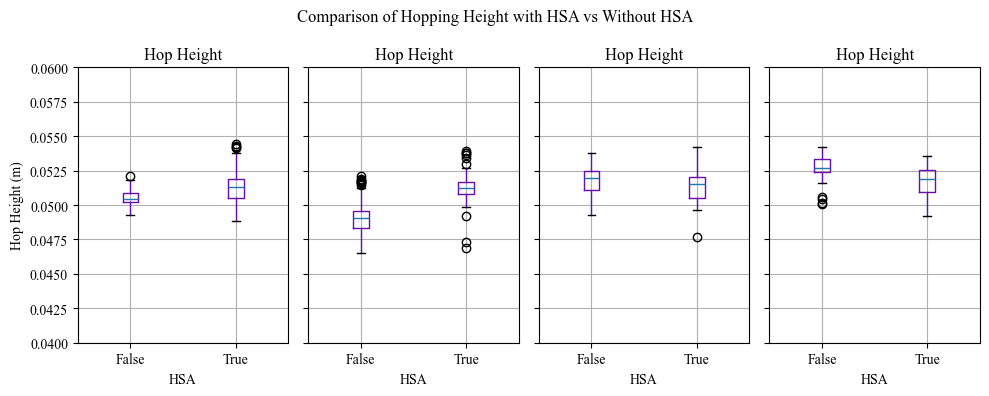

In [13]:
# looks like we can safely filter outliers by standard deviation / z-score on ouputs
masses = summary_df['Mass'].unique()
fig, axs = plt.subplots(nrows=1,ncols=len(masses),sharey=True,figsize=(10,4))
HSA_frame = summary_df['HSA'] == True
NO_HSA_frame = summary_df['HSA'] == False
for i, mass in enumerate(masses):
    mass_frame = summary_df_filt['Mass'] == mass
    summary_df_filt[mass_frame].boxplot(column='Hop Height', by='HSA', ax=axs[i])
    
axs[0].set_ylabel('Hop Height (m)')
axs[0].set_ylim(.04,.06)
fig.suptitle('Comparison of Hopping Height with HSA vs Without HSA')
fig.tight_layout()

HSA
(1.3, 'Thermal Loss')
0.0716739736598444

Control
(1.3, 'Thermal Loss')
0.16904172400672346

HSA
(1.3, 'Positive Motor Work')
0.6972612730326762

Control
(1.3, 'Positive Motor Work')
0.2099389968814902

HSA
(1.3, 'Negative Motor Work')
0.22436319812000793

Control
(1.3, 'Negative Motor Work')
0.2927626606611229

HSA
(1.3, 'Electrical Loss')
0.49656300021418565

Control
(1.3, 'Electrical Loss')
0.13297947121518727

HSA
(1.5, 'Thermal Loss')
0.04418055373340868

Control
(1.5, 'Thermal Loss')
0.4866811060946187

HSA
(1.5, 'Positive Motor Work')
0.28854305389105905

Control
(1.5, 'Positive Motor Work')
0.20213003103263705

HSA
(1.5, 'Negative Motor Work')
0.19131125037643903

Control
(1.5, 'Negative Motor Work')
0.6882221432401725

HSA
(1.5, 'Electrical Loss')
0.09258401938439598

Control
(1.5, 'Electrical Loss')
0.10129114824653518

HSA
(1.7, 'Thermal Loss')
0.05254140227292681

Control
(1.7, 'Thermal Loss')
0.2827057318696109

HSA
(1.7, 'Positive Motor Work')
0.502075887762212

Contr

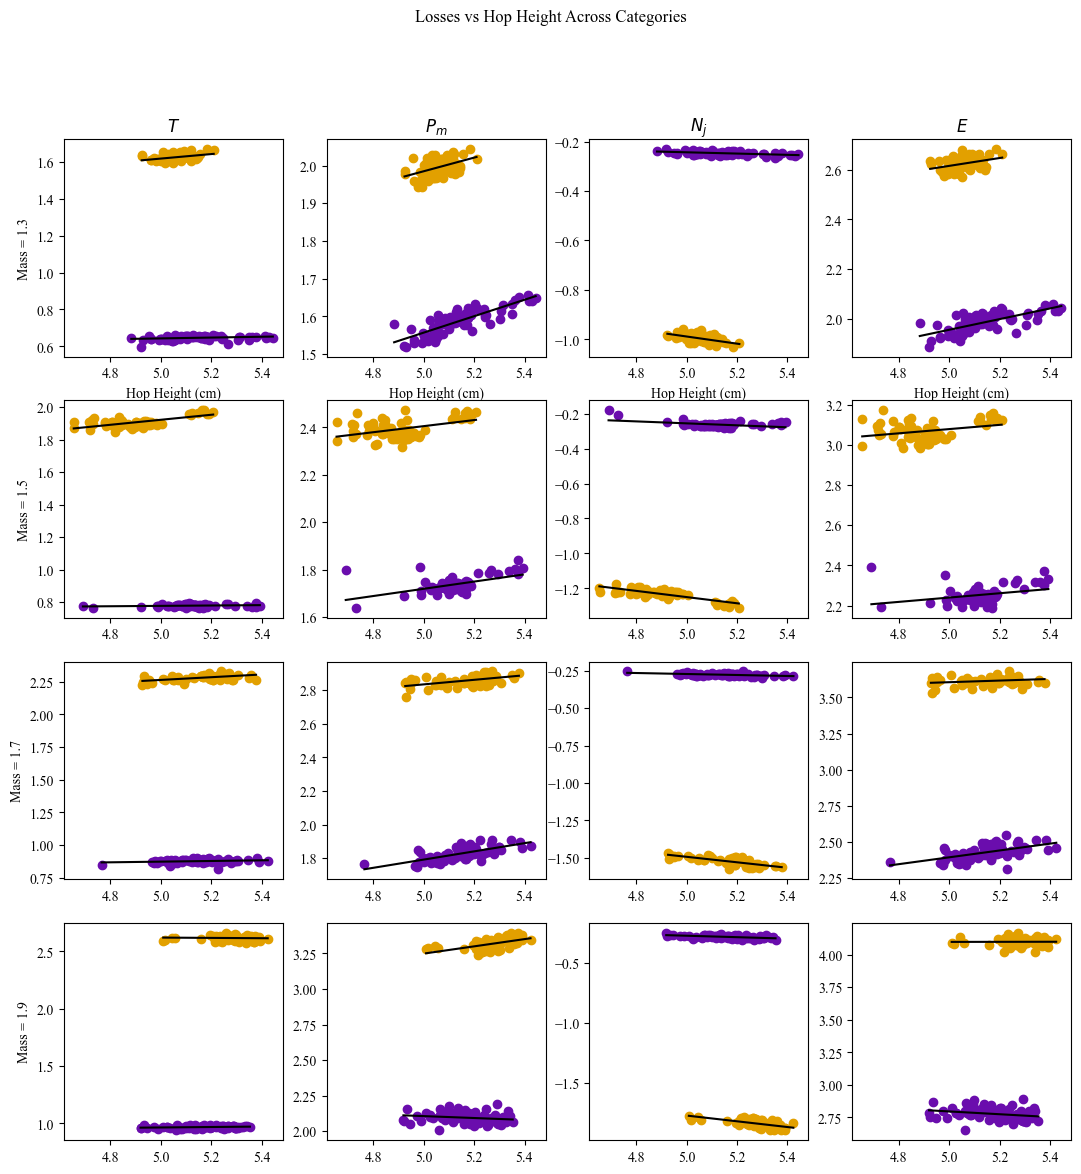

In [ ]:
from scipy.stats.mstats import linregress
import scipy.stats
# Need to look at the difference in normalized losses and make sure they are not correlating too strongly
# with the hop height - otherwise I will need to retake some data
"""
Take losses without HSA, subtract losses with HSA, and plot against difference in hop heights.
Will have the outliers filtered for this state.
Hopefully the data is not super strongly correlated
"""

hsa_loss_predictions = {
}

no_hsa_loss_predictions = {
}

keys = ['Thermal Loss', 
        'Positive Motor Work', 
        'Negative Motor Work', 
        # 'Positive Joint Work', 
        # 'Negative Joint Work', 
        'Electrical Loss']
labels = [r'$T$', r'$P_m$', r'$N_j$', r'$E$']
masses = summary_df_filt['Mass'].unique()
fig, axs = plt.subplots(nrows = len(masses), ncols = len(keys), figsize=(13,13), sharex=True)
Y_PRED = .052
HSA_frame = summary_df_filt['HSA'] == True
NO_HSA_frame = summary_df_filt['HSA'] == False
poly_fit = lambda coeffs, x: sum(coeffs[i]*x**i for i in range(coeffs.size))
poly_degree = 1
for i, mass in enumerate(masses):
    mass_frame = summary_df_filt['Mass'] == mass
    hsa_loss_predictions[mass] = {}
    no_hsa_loss_predictions[mass] = {}
    for j, key in enumerate(keys):
        frame = mass_frame & HSA_frame
        x_hsa = 100*summary_df_filt.loc[frame, 'Hop Height'].to_numpy()
        y_hsa = summary_df_filt.loc[frame, key].to_numpy()
        A_hsa = np.vstack(list(x_hsa**i for i in range(poly_degree+1)))
        hsa_coeffs, hsa_res, rank, s = np.linalg.lstsq(A_hsa.T,y_hsa,rcond=None)
        
        axs[i,j].scatter(x_hsa,y_hsa,color='C0')
        x_fit = np.linspace(min(x_hsa),max(x_hsa),100)
        y_fit = poly_fit(hsa_coeffs,x_fit)
        axs[i,j].plot(x_fit,y_fit,color='black')

        frame = mass_frame & NO_HSA_frame
        x_no_hsa = 100*summary_df_filt.loc[frame, 'Hop Height'].to_numpy()
        y_no_hsa = summary_df_filt.loc[frame,key].to_numpy()
        A_no_hsa = np.vstack(list(x_no_hsa**i for i in range(poly_degree+1)))
        no_hsa_coeffs, no_hsa_res, rank, s = np.linalg.lstsq(A_no_hsa.T,y_no_hsa,rcond=None)
        x_fit = np.linspace(min(x_no_hsa),max(x_no_hsa),100)
        y_fit = poly_fit(no_hsa_coeffs, x_fit)
        axs[i,j].scatter(x_no_hsa,y_no_hsa,color='C1')
        axs[i,j].plot(x_fit,y_fit,color='black')
        axs[0,j].set_title(labels[j])
        axs[i,0].set_ylabel(f'Mass = {mass}')
        axs[0,j].set_xlabel('Hop Height (cm)')
        axs[i,j].tick_params(labelbottom=True)

        # mean_x = (np.sum(x_hsa)+np.sum(x_no_hsa))/(len(x_hsa)+len(x_no_hsa))
        y1 = poly_fit(hsa_coeffs,x_hsa)
        y2 = poly_fit(no_hsa_coeffs, x_no_hsa)


        # estimate the losses at x=5cm
        z = Y_PRED
        alpha = .05
        t_crit = scipy.stats.t.ppf(alpha/2,len(x_hsa)-2)
        x_mean = np.average(x_hsa)
        y_mean = np.average(y_hsa)
        x_std = np.std(x_hsa)
        res = y1 - y_hsa
        y_std = np.std(res)
        r_sqr = 1-np.sum(res**2)/np.sum((y_hsa-y_mean)**2)
        print('HSA')
        print((mass, key))
        print(r_sqr)
        print()
        SEy_z = y_std*np.sqrt(1/len(x_hsa) + ((z-x_mean)**2) / np.sum((x_hsa-x_mean)**2))
        yerr = abs(t_crit)*SEy_z
        xerr = x_std/np.sqrt(x_hsa.size) + abs(z-x_mean)
        hsa_loss_predictions[mass][key] = (z,y,yerr,xerr,r_sqr)

        x_mean = np.average(x_no_hsa)
        y_mean = np.average(y_no_hsa)
        x_std = np.std(x_no_hsa)
        res = y2 - y_no_hsa
        y_std = np.std(res)
        r_sqr = 1-np.sum(res**2)/np.sum((y_no_hsa-y_mean)**2)
        print('Control')
        print((mass, key))
        print(r_sqr)
        print()
        SEy_z = y_std*np.sqrt(1/len(x_no_hsa) + ((z-x_mean)**2) / np.sum((x_no_hsa-x_mean)**2))
        yerr = abs(t_crit)*SEy_z
        xerr = x_std/np.sqrt(x_no_hsa.size) + abs(z-x_mean)
        no_hsa_loss_predictions[mass][key] = (z,y,yerr,xerr,r_sqr)

    fig.suptitle('Losses vs Hop Height Across Categories')
plt.savefig('Losses_vs_height.png')

In [15]:

"""
Different version of the primary results plot:

(A) percent reduction in COT across mass conditions, with confidence intervals
(B) change in Thermal loss vs Mechanical Loss... whether to normalize by mgh or just h is an open question
(C) direct comparison of VCOT
"""

from matplotlib.gridspec import GridSpec
import matplotlib.ticker as mtick

elec = summary_df_filt['Electrical Loss']
therm = summary_df_filt['Thermal Loss']
mech = summary_df_filt['Positive Motor Work'] + summary_df_filt['Negative Motor Work']
height = summary_df_filt['Hop Height']
mass = summary_df_filt['Mass']
masses = summary_df_filt['Mass'].unique()

# all calculations
norm = mass*height*9.81
COT = elec / norm

metrics = {
    'COT' : COT,
    'Thermal Loss': therm,
    'Motor Work': mech,
    'Electrical Loss': mech + therm
}

# frame slices
mass_frames = [summary_df_filt['Mass']==m for m in masses]
hsa_frames = [mass_frame & (summary_df_filt['HSA'] == True) for mass_frame in mass_frames]
without_hsa_frames = [mass_frame & (summary_df_filt['HSA'] == False) for mass_frame in mass_frames]


# Bootstrap our metrics to get confidence intervals
z = 2.575 # for 99% confidence
N_bootstrap = 1000
rng = np.random.default_rng(seed=42)
resample = lambda arr: arr[rng.choice(arr.size,arr.size,replace=True)]
hsa_conf= {}
without_hsa_conf = {}
for key, metric in metrics.items():
    X = [metric[frame].to_numpy() for frame in hsa_frames]
    samples = [
        np.stack([resample(arr) for i in range(N_bootstrap)])
        for arr in X 
    ]
    means = np.stack([np.average(sample, axis=1) for sample in samples])
    mean_of_means = np.average(means,axis=1)
    std_of_means = np.std(means,axis=1)
    hsa_conf[key] = np.stack([mean_of_means-z*std_of_means, mean_of_means+z*std_of_means])

    X = [metric[frame].to_numpy() for frame in without_hsa_frames]
    samples = [
        np.stack([resample(arr) for i in range(N_bootstrap)])
        for arr in X 
    ]
    means = np.stack([np.average(sample, axis=1) for sample in samples])
    mean_of_means = np.average(means,axis=1)
    std_of_means = np.std(means,axis=1)
    without_hsa_conf[key] = np.stack([mean_of_means-z*std_of_means, mean_of_means+z*std_of_means])


In [16]:
# Analyzing SPEAR hopping data
M = 4.9
g = 9.81
L1 = .32    # thigh
L2 = .327   # shank
theta_knee = np.array([0.74, 1.07, 1.4])
E_elec = np.array([15,17,19])
dx = np.array([.1,.2,.25])
F_max = 200
L_td = np.sqrt(L1**2+L2**2+L1*L2*np.cos(theta_knee))
E_mech = .5*F_max*dx
E_hop_potential = M*g*dx
print(E_elec/E_hop_potential)

dx_norm = dx / L_td
quad_fit = np.linalg.inv(np.array([[dx[0]**2, dx[0], 1],
              [dx[1]**2, dx[1], 1],
              [dx[2]**2, dx[2], 1]])) @ E_elec

cost_of_transport = E_elec/(M*9.81*dx)

SPEAR_COT_COMP = cost_of_transport[0]

[3.12051426 1.76829141 1.58106056]


35.16570318008517


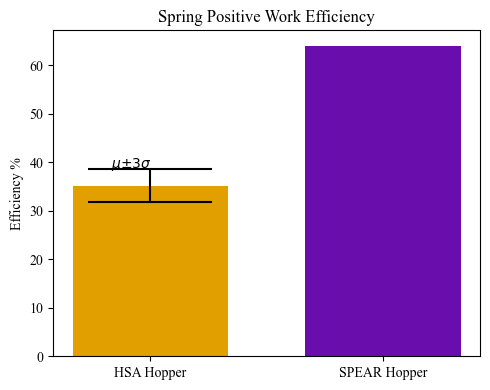

In [42]:
with_hsa = summary_df_filt['HSA'] == True
frame = with_hsa & (summary_df_filt['Mass'] == 1.9)
hsa_spring_eff = 100*(1-summary_df_filt.loc[frame, 'Stance Positive Motor Work'] / summary_df_filt.loc[frame, 'Stance Positive Joint Work'])
spear_spring_eff = 64
fig, ax = plt.subplots(figsize=(5,4))
ax.bar([0], [hsa_spring_eff.mean()], width=.1, yerr=[3*hsa_spring_eff.std()], color='C1')
ax.bar([.15], [spear_spring_eff], width=.1, color='C0')
ax.hlines([hsa_spring_eff.mean()+3*hsa_spring_eff.std(),hsa_spring_eff.mean()-3*hsa_spring_eff.std()], xmin=[-.04, -.04], xmax=[.04,.04], color='black')
ax.set_ylabel('Efficiency %')
ax.set_xticks([0,.15])
ax.set_xticklabels(['HSA Hopper', 'SPEAR Hopper'])
ax.set_title('Spring Positive Work Efficiency')
ax.annotate(r'$\mu ± 3\sigma$', (-.025,hsa_spring_eff.mean() + 3.3*hsa_spring_eff.std()))
fig.tight_layout()
print(hsa_spring_eff.mean())
fig.savefig('spring_pos_work_eff', dpi=900)

In [18]:
class SlipInterp:
    def __init__(self, L: float, omega: float, t_stance: float, knots = 2, degree=3):
        self.L = L
        self.omega = omega
        self.t_stance = t_stance
        self.knots = knots
        self.degree = degree
        self.position_coeffs = np.zeros((2, degree+1, knots+1))
        self.tk = tk = t_stance/2*(1+np.cos(np.linspace(-np.pi,0,knots+2)))
        self.tmat = np.zeros((3,degree+1))
        self.tmat[[0],:] = interp_covector(0,0,1,degree+1)
        self.tmat[[1],:] = interp_covector(.5,0,1,degree+1)
        self.tmat[[2],:] = interp_covector(1,0,1,degree+1)
        self.dt = np.diff(tk)
        self.diff = diff_tensor(0,1,degree+1)

    def set_from_array(self, arr: np.ndarray):
        self.position_coeffs = np.reshape(arr, (2,self.degree+1,self.knots+1), order='F')

    def get_array(self):
        return np.reshape(self.position_coeffs, self.position_coeffs.size, order='F')
    
    def evaluate_knots(self):
        vel_coeffs = np.einsum('ij,kjl->kil', self.diff, self.position_coeffs)/self.dt
        acc_coeffs = np.einsum('ij,kjl->kil', self.diff, vel_coeffs)/self.dt
        pos = np.einsum('ij,kjl->kil', self.tmat, self.position_coeffs)
        vel = np.einsum('ij,kjl->kil', self.tmat, vel_coeffs)
        acc = np.einsum('ij,kjl->kil', self.tmat, acc_coeffs)
        return pos, vel, acc
    
    def interpolate(self, t, ord=0):
        pos = np.zeros((2,t.size))
        for i in range(t.size):
            j = next(j for j in range(self.knots+1) if self.tk[j] <= t[i] <= self.tk[j+1])
            t_eval = interp_covector(t[i], self.tk[j], self.tk[j+1], self.degree+1, ord=ord)
            pos[:,[i]] = np.einsum('ij,kj->ki', t_eval, self.position_coeffs[:,:,j])
        return pos
    
    def fit_interp(self, pos, tvec):
        # least-squares interpolation fit to pos(t)
        self.position_coeffs = np.zeros(self.position_coeffs.shape)
        for i in range(self.knots+1):
            t_idx = np.array([j for j,t in enumerate(tvec) if self.tk[i] <= t <= self.tk[i+1]])
            N = t_idx.size
            A = np.zeros((N, self.degree+1))
            b = np.zeros((N, 2))
            for j in range(t_idx.size):
                A[j,:] = interp_covector(tvec[t_idx[j]], self.tk[i], self.tk[i+1], self.degree+1)
                b[j,:] = pos[:,t_idx[j]]
            coeffs, res, rank, sigma = np.linalg.lstsq(A,b)
            self.position_coeffs[0,:,i] = coeffs[:,0]
            self.position_coeffs[1,:,i] = coeffs[:,1]

    def make_initial_guess(self, theta_td: float):
        tvec = np.linspace(0,self.t_stance,2*(self.knots+1)*self.degree)
        x0 = -self.L*np.sin(theta_td)
        dx = -2*x0
        x = np.linspace(x0,x0+dx,tvec.size)
        y0 = self.L*np.cos(theta_td)
        dy = .01*L
        y = y0-dy*np.sin(np.pi/self.t_stance*tvec)
        pos = np.zeros((2,tvec.size))
        pos[0,:] = x
        pos[1,:] = y
        self.fit_interp(pos, tvec)

    def compute_positive_work(self):
        tvec = np.linspace(0,self.t_stance,2*(self.knots+1)*self.degree)
        pos = self.interpolate(tvec)
        vel = self.interpolate(tvec, ord=1)
        acc = self.interpolate(tvec, ord=2)
        l = np.sqrt(pos[0,:]**2 + pos[1,:]**2)
        Fx = (self.omega**2)*(self.L-l)*pos[0,:]/l
        Fy = (self.omega**2)*(self.L-l)*pos[1,:]/l
        Wx = np.trapz(np.clip(Fx*vel[0,:],0,np.inf),x=tvec)
        Wy = np.trapz(np.clip(Fy*vel[1,:],0,np.inf),x=tvec)
        return np.array([Wx,Wy])
    
    def compute_horizontal_speed(self):
        t = np.array([0,self.t_stance])
        p = self.interpolate(t)
        v = self.interpolate(t,ord=1)
        t_flight = 2*v[1,1]/9.81
        dx = p[0,1]-p[0,0]
        dx_total = dx + v[0,1]*t_flight
        xdot_avg = dx_total / (t_flight+self.t_stance)
        return dx_total, xdot_avg

    def compute_height_gain(self):
        t = np.array([0,self.t_stance])
        v = self.interpolate(t,ord=1)
        return (v[1,-1]**2)/(2*9.81)

    def dynamics(self, pos: np.ndarray):
        if len(pos.shape) < 2:
            _p = pos[:,np.newaxis]
        else:
            _p = pos
        l = np.sqrt(_p[0,:]**2+_p[1,:]**2)
        f = np.zeros_like(_p)
        f[0,:] = (self.omega**2)*(self.L-l)*_p[0,:,:]/l
        f[1,:] = (self.omega**2)*(self.L-l)*_p[1,:,:]/l-9.81
        return f


In [19]:
class SlipBC:
    def __init__(self, A: np.ndarray, B: np.ndarray, c: np.ndarray, initial_value = True):
        self.initial_value = initial_value
        self.A = A
        self.B = B
        self.c = c

    def eval(self, pos, vel):
        
        if self.initial_value:
            return self.A@pos[:,0,0] + self.B@vel[:,0,0] + self.c
        else:
            return self.A@pos[:,-1,-1] + self.B@vel[:,-1,-1] + self.c

class SlipBVP:
    def __init__(self, slerp: SlipInterp, bcs: list[SlipBC]):
        self.slerp = slerp
        self.bcs = bcs

    def continuity_constraints(self, pos: np.ndarray, vel: np.ndarray):
        c = np.zeros((4,self.slerp.knots))
        for i in range(c.shape[1]):
            c[0:2,i] = pos[:,-1,i] - pos[:,0,i+1]
            c[2:,i] = vel[:,-1,i] - vel[:,0,i+1]
        return c

    def dynamic_constraints(self, pos: np.ndarray, acc: np.ndarray):
        c = self.slerp.dynamics(pos[:,[1],:]) - acc[:,[1],:]
        return c
    
    def contact_constraints(self, acc: np.ndarray):
        return acc[1,:,:]+9.81 # non-negative constraint
    
    def boundary_conditions(self, pos: np.ndarray, vel: np.ndarray):
        return np.stack([bc.eval(pos,vel) for bc in self.bcs], axis=0)
    
    def equality_constraints(self, arr: np.ndarray):
        self.slerp.set_from_array(arr)
        pos, vel, acc = self.slerp.evaluate_knots()
        c1 = self.continuity_constraints(pos,vel)
        c2 = self.dynamic_constraints(pos,acc)

        all_constraints = np.hstack(
            [
                c1.flatten(order='F'),
                c2.flatten(order='F'),
            ]
        ) 
        if len(self.bcs) > 0:
            return np.hstack(
                [all_constraints, 
                 self.boundary_conditions(pos,vel).flatten()])

        return all_constraints
    
    def inequality_constraints(self, arr: np.ndarray):
        pos, vel, acc = self.slerp.evaluate_knots()
        return self.contact_constraints(acc).flatten()
    
"""
Example initial guess for stance boundary conditions,
L = neutral leg length for SLIP
t_stance = stance period
theta_td = stance touchdown angle
dx = stance horizontal distance traveled
dy = stance vertical distnace traveled
"""
def symmetric_stance_bvp(slerp: SlipInterp, theta_td: float):
    slerp.make_initial_guess(theta_td)
    p0 = slerp.interpolate(np.array([0]))

    bcs = [
        SlipBC(np.array([[1,0,]]), np.zeros((1,2)), -np.array([p0[0]])),
        SlipBC(np.array([[0,1]]), np.zeros((1,2)), -np.array([p0[1]])),
        SlipBC(np.array([[0,1]]), np.zeros((1,2)), -np.array([p0[1]]), initial_value=False),
    ]
    bvp = SlipBVP(slerp, bcs)
    arr = slerp.get_array()
    bvp.equality_constraints(arr)
    bvp.inequality_constraints(arr)

    dummy_cost = lambda arr: 0

    from scipy.optimize import minimize
    result = minimize(dummy_cost, arr, method='SLSQP',
                constraints = [
                    {'type' : 'eq', 'fun' : lambda arr: bvp.equality_constraints(arr)},
                    {'type' : 'ineq', 'fun': lambda arr: bvp.inequality_constraints(arr), 'lb' : 0, 'ub' : np.inf}
                ]
    )
    slerp.set_from_array(result.x)
    return slerp


In [20]:

# xdot_avg_spear = np.array([0.54, ])
""" Interpolating data from SPEAR horizontal running """
pix_coords = np.array([
    [154,60],
    [190,166],
    [242,272],
    [318,336],
    [413,396],
    [531,413],
    [681,454],
    [777,467]
])

pix_origin = np.array([[163,451]])

pix_scale = np.array([[.4/566, 1./112]])

xdot_spear = (pix_coords[:,0]-pix_origin[0,0])*pix_scale[0,0] + 0.1
h_cot_spear = (pix_origin[0,1]-pix_coords[:,1])*pix_scale[0,1] + 1



from scipy.optimize import root_scalar
h_eq = np.zeros_like(xdot_spear)
v_cot_eq = np.zeros_like(h_cot_spear)
t_stance = 0.36
# omega = 1.4*np.pi/t_stance
K = 1000
M = 4.91
omega = np.sqrt(K/M)
L = .5
slerp = SlipInterp(L,omega,t_stance,knots=20,degree=2)
for i in range(xdot_spear.size):
    f = lambda theta_td: symmetric_stance_bvp(slerp,theta_td).compute_horizontal_speed()[1]-xdot_spear[i]
    theta_lb = 1*np.pi/180
    theta_ub = 15*np.pi/180
    result = root_scalar(f, bracket=(theta_lb,theta_ub))
    print(result)
    if result.converged:
        dx, xdot = slerp.compute_horizontal_speed()
        W = slerp.compute_positive_work()
        h_eq[i] = np.sum(W/(2*9.81))
        v_cot_eq[i] = h_cot_spear[i]*dx/h_eq[i]


C:\Users\Joseph Sullivan\AppData\Local\Temp\ipykernel_13396\1975031087.py:50: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  coeffs, res, rank, sigma = np.linalg.lstsq(A,b)


      converged: True
           flag: converged
 function_calls: 8
     iterations: 7
           root: 0.03520201579297015
         method: brentq
      converged: True
           flag: converged
 function_calls: 9
     iterations: 8
           root: 0.04476910607696876
         method: brentq
      converged: True
           flag: converged
 function_calls: 11
     iterations: 10
           root: 0.058591957032018034
         method: brentq
      converged: True
           flag: converged
 function_calls: 15
     iterations: 14
           root: 0.0788053433091545
         method: brentq
      converged: True
           flag: converged
 function_calls: 7
     iterations: 6
           root: 0.10409734495031663
         method: brentq
      converged: True
           flag: converged
 function_calls: 14
     iterations: 13
           root: 0.135569307817958
         method: brentq
      converged: True
           flag: converged
 function_calls: 15
     iterations: 14
           root: 0.

[0.34221252 0.31435306 0.21796521 0.32769002]
[-0.98013754 -1.13109771 -1.40603907 -1.6475561 ]


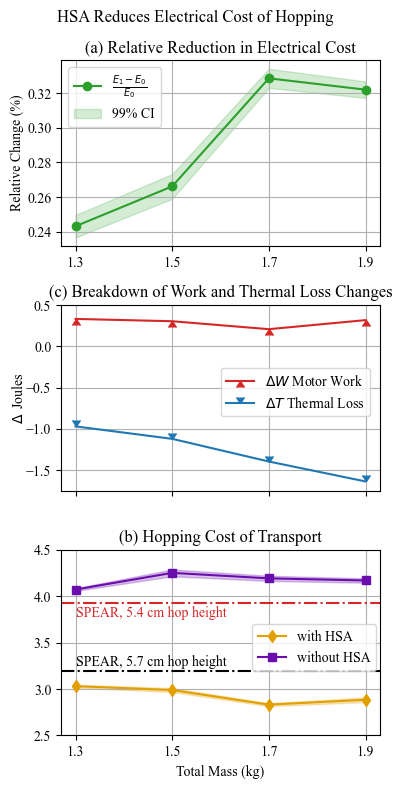

In [21]:

from matplotlib.gridspec import GridSpec
import matplotlib.ticker as mtick
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(4,8), sharex=True)


# first figure, reduction in cost of transport
C0 = without_hsa_conf['Electrical Loss']
C1 = hsa_conf['Electrical Loss']
E0 = (C0[0,:]+C0[1,:])/2
E1 = (C1[0,:]+C1[1,:])/2
Y = 1 - E1/E0
LB = 1-C1[1,:]/C0[0,:]
UB = 1-C1[0,:]/C0[1,:]

axs[0].plot(masses, Y, color='C3', marker='o', label=r'$\frac{E_1-E_0}{E_0}$')
axs[0].fill_between(masses, LB, UB, color='C3', alpha=.2, label='99% CI')
# axs[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axs[0].xaxis.set_tick_params(labelbottom=True)
axs[0].legend()
axs[0].grid(visible=True)
axs[0].set_ylabel('Relative Change (%)',labelpad=2)
axs[0].set_title('(a) Relative Reduction in Electrical Cost')


# second figure is change in TCOT and MCOT

C0 = without_hsa_conf['Motor Work']
C1 = hsa_conf['Motor Work']
W0 = (C0[0,:]+C0[1,:])/2
W1 = (C1[0,:]+C1[1,:])/2
Y = W1-W0
print(Y)
axs[1].plot(masses, Y-.01, label=r'$ΔW$ Motor Work', marker=6, color='C5')


C0 = without_hsa_conf['Thermal Loss']
C1 = hsa_conf['Thermal Loss']
T0 = (C0[0,:]+C0[1,:])/2
T1 = (C1[0,:]+C1[1,:])/2
Y = T1-T0
print(Y)
axs[1].plot(masses, Y+.01, label=r'$ΔT$ Thermal Loss', marker=7, color='C2')

axs[1].set_ylabel(r'$Δ \,$ Joules',labelpad=0)
axs[1].set_title('(c) Breakdown of Work and Thermal Loss Changes')
axs[1].set_ylim(-1.75, .5)
axs[1].grid(visible=True)
axs[1].legend(loc=(.5, .4))
axs[1].set_xticks(ticks=masses)


C = hsa_conf['COT']
Y = (C[0,:]+C[1,:])/2
hop_avg = summary_df_filt.loc[summary_df_filt['HSA']==True, 'Hop Height'].mean()
axs[2].plot(masses, Y, color='C1', marker='d', label='with HSA')
axs[2].fill_between(masses, C[0,:], C[1,:], alpha=.25, color='C1')

C = without_hsa_conf['COT']
Y = (C[0,:]+C[1,:])/2
hop_avg = summary_df_filt.loc[summary_df_filt['HSA']==True, 'Hop Height'].mean()
axs[2].plot(masses, Y, color='C0', marker='s', label=rf'without HSA')
axs[2].fill_between(masses, C[0,:], C[1,:], alpha=.25, color='C0')

imin = np.argmin(v_cot_eq)
axs[2].axhline(y=v_cot_eq[imin],color='black', linestyle='-.')
axs[2].annotate(f'SPEAR, {100*h_eq[imin]:.1f} cm hop height', [1.3,v_cot_eq[imin]+.05], color='black')
imax = np.argmax(v_cot_eq)
axs[2].axhline(y=v_cot_eq[imax],color='C5', linestyle='-.')
axs[2].annotate(f'SPEAR, {100*h_eq[imax]:.1f} cm hop height', [1.3,v_cot_eq[imax]-.15], color='C5')
# axs[2].axhline(y=2.9,color='black', linestyle='-.')
# axs[2].annotate(f'SPEAR, 11 cm hop height', [1.3,2.9-.15], color='black')
axs[2].set_title('(b) Hopping Cost of Transport')
axs[2].xaxis.set_tick_params(labelbottom=True)
axs[2].grid(visible=True)
axs[2].legend(loc=(.6,.35))
axs[2].set_ylim(2.5, 4.5)
axs[2].set_xlabel('Total Mass (kg)')


fig.suptitle('HSA Reduces Electrical Cost of Hopping')
fig.tight_layout()
fig.savefig('hopping_results.png', dpi=1200)

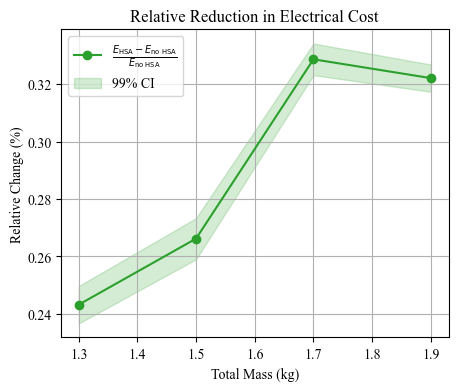

In [41]:
# Relative Change, by itself
fig, axs = plt.subplots(figsize=(5,4))

# first figure, reduction in cost of transport
C0 = without_hsa_conf['Electrical Loss']
C1 = hsa_conf['Electrical Loss']
E0 = (C0[0,:]+C0[1,:])/2
E1 = (C1[0,:]+C1[1,:])/2
Y = 1 - E1/E0
LB = 1-C1[1,:]/C0[0,:]
UB = 1-C1[0,:]/C0[1,:]

axs.plot(masses, Y, color='C3', marker='o', label=r'$\frac{E_\text{HSA}-E_\text{no HSA}}{E_\text{no HSA}}$')
axs.fill_between(masses, LB, UB, color='C3', alpha=.2, label='99% CI')
axs.xaxis.set_tick_params(labelbottom=True)
axs.legend()
axs.grid(visible=True)
axs.set_ylabel('Relative Change (%)',labelpad=2)
axs.set_title('Relative Reduction in Electrical Cost')
axs.set_xlabel('Total Mass (kg)')
fig.savefig('cost_reduction.png',dpi=900)

[0.34221252 0.31435306 0.21796521 0.32769002]
[-0.98013754 -1.13109771 -1.40603907 -1.6475561 ]


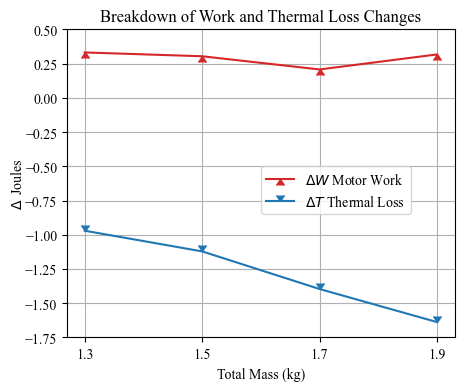

In [40]:
# Thermal stuff
fig, axs = plt.subplots(figsize=(5,4))

C0 = without_hsa_conf['Motor Work']
C1 = hsa_conf['Motor Work']
W0 = (C0[0,:]+C0[1,:])/2
W1 = (C1[0,:]+C1[1,:])/2
Y = W1-W0
print(Y)
axs.plot(masses, Y-.01, label=r'$ΔW$ Motor Work', marker=6, color='C5')

C0 = without_hsa_conf['Thermal Loss']
C1 = hsa_conf['Thermal Loss']
T0 = (C0[0,:]+C0[1,:])/2
T1 = (C1[0,:]+C1[1,:])/2
Y = T1-T0
print(Y)
axs.plot(masses, Y+.01, label=r'$ΔT$ Thermal Loss', marker=7, color='C2')

axs.set_ylabel(r'$Δ \,$ Joules',labelpad=0)
axs.set_title('Breakdown of Work and Thermal Loss Changes')
axs.set_ylim(-1.75, .5)
axs.grid(visible=True)
axs.legend(loc=(.5, .4))
axs.set_xticks(ticks=masses)
axs.set_xlabel('Total Mass (kg)')
fig.savefig('work_vs_joule.png',dpi=900)

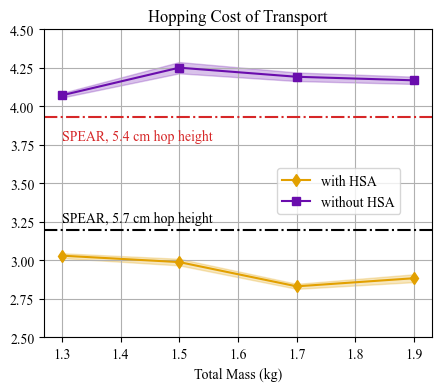

In [39]:
fig, axs = plt.subplots(figsize=(5,4))
C = hsa_conf['COT']
Y = (C[0,:]+C[1,:])/2
hop_avg = summary_df_filt.loc[summary_df_filt['HSA']==True, 'Hop Height'].mean()
axs.plot(masses, Y, color='C1', marker='d', label='with HSA')
axs.fill_between(masses, C[0,:], C[1,:], alpha=.25, color='C1')

C = without_hsa_conf['COT']
Y = (C[0,:]+C[1,:])/2
hop_avg = summary_df_filt.loc[summary_df_filt['HSA']==True, 'Hop Height'].mean()
axs.plot(masses, Y, color='C0', marker='s', label=rf'without HSA')
axs.fill_between(masses, C[0,:], C[1,:], alpha=.25, color='C0')

imin = np.argmin(v_cot_eq)
axs.axhline(y=v_cot_eq[imin],color='black', linestyle='-.')
axs.annotate(f'SPEAR, {100*h_eq[imin]:.1f} cm hop height', [1.3,v_cot_eq[imin]+.05], color='black')
imax = np.argmax(v_cot_eq)
axs.axhline(y=v_cot_eq[imax],color='C5', linestyle='-.')
axs.annotate(f'SPEAR, {100*h_eq[imax]:.1f} cm hop height', [1.3,v_cot_eq[imax]-.15], color='C5')
# axs[2].axhline(y=2.9,color='black', linestyle='-.')
# axs[2].annotate(f'SPEAR, 11 cm hop height', [1.3,2.9-.15], color='black')
axs.set_title('Hopping Cost of Transport')
axs.xaxis.set_tick_params(labelbottom=True)
axs.grid(visible=True)
axs.legend(loc=(.6,.4))
axs.set_ylim(2.5, 4.5)
axs.set_xlabel('Total Mass (kg)')

fig.savefig('cost_of_transport.png', dpi=900)

HSA Hop Height mean: 0.051433417864496345, Std: 0.0011682090789059572
Without HSA Hop Height mean: 0.050991284986417, Std: 0.0016899315732376036


(array([ 7.,  8., 16., 32., 39., 37., 35., 55., 28., 16.]),
 array([0.04654424, 0.04731366, 0.04808309, 0.04885251, 0.04962194,
        0.05039136, 0.05116078, 0.05193021, 0.05269963, 0.05346906,
        0.05423848]),
 <BarContainer object of 10 artists>)

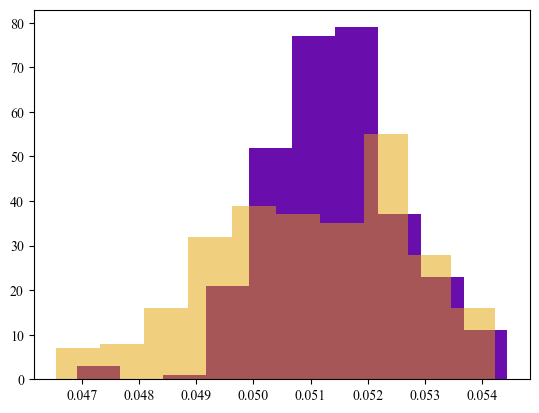

In [23]:
frame = summary_df_filt['HSA'] == True
hop_avg = summary_df_filt.loc[frame, 'Hop Height'].mean()
hop_std = summary_df_filt.loc[frame, 'Hop Height'].std()
print(f'HSA Hop Height mean: {hop_avg}, Std: {hop_std}')
plt.hist(summary_df_filt.loc[frame, 'Hop Height'])
frame = summary_df_filt['HSA'] == False
hop_avg = summary_df_filt.loc[frame, 'Hop Height'].mean()
hop_std = summary_df_filt.loc[frame, 'Hop Height'].std()
print(f'Without HSA Hop Height mean: {hop_avg}, Std: {hop_std}')
plt.hist(summary_df_filt.loc[frame, 'Hop Height'], alpha = .5)

In [24]:
print((100*summary_df_filt['Hop Height']).mean())
print((100*summary_df_filt['Hop Height']).std()**2)

5.122422847850733
0.021153141927453982


In [25]:
hsa_frame = summary_df_filt['HSA'] == True
without_frame = summary_df_filt['HSA'] == False

for mass in summary_df_filt['Mass'].unique():
    mass_frame = summary_df_filt['Mass'] == mass
    stat = summary_df_filt.loc[mass_frame & hsa_frame, 'Negative Motor Work'].mean() / summary_df_filt.loc[mass_frame&without_frame,'Negative Motor Work'].mean()
    print(f'Mass = {mass}')
    hsa_hops = sum(mass_frame & hsa_frame)
    without_hops = sum(mass_frame & without_frame)
    print(f'Number of hops: {(hsa_hops, without_hops)}')
    print(f'Average reduction in negative motor work: {1-stat:.1f}')

Mass = 1.3
Number of hops: (77, 72)
Average reduction in negative motor work: 0.8
Mass = 1.5
Number of hops: (73, 69)
Average reduction in negative motor work: 0.8
Mass = 1.7
Number of hops: (78, 66)
Average reduction in negative motor work: 0.8
Mass = 1.9
Number of hops: (76, 66)
Average reduction in negative motor work: 0.8


In [26]:
# need to get all the controller parameters ready for a table

control_params = {
'Mass' : [],
'HSA' : [],
'Kf' : [],
'bf' : [],
'Ks' : [],
'bs' : [],
'u min' : [],
'u max' : [],
}
for cond, trials in conditions.items():
    HSA = 'no_hsa' not in cond
    mass = trials[0]['experiment_config']['mass']/1000
    Kf = trials[0]['experiment_config']['controller']['kp'][1]
    bf = trials[0]['experiment_config']['controller']['kd'][1]
    Ks = trials[0]['experiment_config']['controller']['kp'][3]
    bs = trials[0]['experiment_config']['controller']['kd'][3]
    u = [trial['experiment_config']['controller']['u_ff'] for trial in trials]
    control_params['Mass'].append(mass)
    control_params['HSA'].append(HSA)
    control_params['Kf'].append(Kf)
    control_params['bf'].append(bf)
    control_params['Ks'].append(Ks)
    control_params['bs'].append(bs)
    control_params['u min'].append(min(u))
    control_params['u max'].append(max(u))

control_param_df = pd.DataFrame(control_params)

In [27]:
# print(control_param_df.to_latex())
latex_str = control_param_df.to_latex(float_format = "%.2f", formatters={'HSA' : lambda b: 'with HSA' if b else 'without HSA' })
print(latex_str)

\begin{tabular}{lrrrrrrll}
\toprule
 & Mass & HSA & Kf & bf & Ks & bs & u min & u max \\
\midrule
0 & 1.30 & with HSA & 0.00 & 0.07 & 0.00 & 0.00 & [0.0, 0.0, 0.0, -2.75] & [0.0, 0.0, 0.0, -2.75] \\
1 & 1.50 & with HSA & 0.00 & 0.07 & 0.00 & 0.00 & [0.0, 0.0, 0.0, -2.85] & [0.0, 0.0, 0.0, -2.85] \\
2 & 1.70 & with HSA & 0.00 & 0.07 & 0.00 & 0.00 & [0.0, 0.0, 0.0, -3.25] & [0.0, 0.0, 0.0, -3.25] \\
3 & 1.90 & with HSA & 0.00 & 0.07 & 0.00 & 0.00 & [0.0, 0.0, 0.0, -3.25] & [0.0, 0.0, 0.0, -3.25] \\
4 & 1.30 & without HSA & 2.70 & 0.10 & 2.70 & 0.10 & [0.0, 0.0, 0.0, -3.2] & [0.0, 0.0, 0.0, -3.2] \\
5 & 1.50 & without HSA & 2.70 & 0.10 & 2.70 & 0.10 & [0.0, 0.0, 0.0, -3.1] & [0.0, 0.0, 0.0, -3.1] \\
6 & 1.70 & without HSA & 2.70 & 0.10 & 2.70 & 0.10 & [0.0, 0.0, 0.0, -3.1] & [0.0, 0.0, 0.0, -3.1] \\
7 & 1.90 & without HSA & 2.70 & 0.10 & 2.70 & 0.10 & [0.0, 0.0, 0.0, -3.1] & [0.0, 0.0, 0.0, -3.1] \\
\bottomrule
\end{tabular}

